<a href="https://colab.research.google.com/github/DarioCorona/personal/blob/root/ejercicio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [62]:
import pandas  as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns # Added seaborn import
import warnings as wg



COLOR_PRINCIPAL  = "#9B004C"   #VARIABLES DE ENTORNO
COLOR_SECUNDARIO = "#C4005E"
COLOR_GRIS       = "#D4D4D4"
COLOR_FONDO      = "#1A1A2E"
COLOR_ACENTO     = "#FF6B9D"

plt.rcParams.update(
      {
      "figure.facecolor"    : COLOR_FONDO, # Corregido de 'figure.factorcolor' a 'figure.facecolor'
      "axes.facecolor"      : "#16213e",
      "axes.edgecolor"      : COLOR_GRIS,
      "axes.labelcolor"     : COLOR_GRIS,
      "xtick.color"         : COLOR_GRIS,
      "ytick.color"         : COLOR_GRIS,
      "text.color"          : "#123456",
      "grid.linestyle"      : "--",
      "grid.alpha"          : 0.5,
      "font.family"         : "Dejavu sans",
      "figure.dpi"          : 110
})

ruta_csv = "/content/MODBUS-RTU.csv"




wg.filterwarnings('ignore')


df = pd.read_csv(ruta_csv)
display(df.head())

,timestamp,voltage_avg_V,voltage_LL_avg_V,current_avg_A,frequency_Hz,voltage_L1_V,voltage_L2_V,voltage_L3_V,voltage_L1_L2_V,voltage_L2_L3_V,...,harmonics_V_L3_L1_net_25_pct,harmonics_V_L1_L2_net_26_pct,harmonics_V_L2_L3_net_26_pct,harmonics_V_L3_L1_net_26_pct,harmonics_V_L1_L2_net_35_pct,harmonics_V_L2_L3_net_35_pct,harmonics_V_L3_L1_net_35_pct,harmonics_V_L1_L2_net_51_pct,harmonics_V_L2_L3_net_51_pct,harmonics_V_L3_L1_net_51_pct
0,01/08/2024 00:00,128.65,222.82,85.97,59.99,128.90,128.28,128.76,222.59,222.35,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
1,01/08/2024 00:05,128.67,222.85,88.99,59.99,128.98,128.26,128.76,222.68,222.29,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
2,01/08/2024 00:10,128.75,223.01,81.08,59.95,129.12,128.36,128.79,222.88,222.43,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
3,01/08/2024 00:15,128.92,223.29,81.72,59.97,129.22,128.51,129.01,223.08,222.72,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0
4,01/08/2024 00:20,128.77,223.04,84.64,60.02,129.04,128.37,128.91,222.77,222.55,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0


In [56]:
df_raw = pd.read_csv(
    ruta_csv,
    sep=",",
    parse_dates= ["timestamp"],
    dayfirst=True, #DDMMYYYY
    low_memory= False
)

In [57]:
df_raw.shape  # numero de filas y columnas  en base de datos //por que me  imprime si  no hay  un print cuando  hay una instruccion al final  siempre va a imprimir  en pantalla  lo que se esta haciendo solo en notebooks imprime  la ultima linea

n_filas,n_columnas = df_raw.shape

print("registros (filas):", n_filas)
print("registros (columnas):", n_columnas)

t_init = df_raw["timestamp"].min()
t_fin  = df_raw["timestamp"].max()

dias = df_raw ["timestamp"].count()

dias = (t_fin-t_init).days  ##en lugar de .days puede ser .seconds etc

freq = df_raw['timestamp'].diff().mode()[0] ## diff diferencia   mode () el mas  comun

##clasificacion de columnas por categorias
cols_voltaje    = [c for c in df_raw if  "voltage" in c and "harmonic" not in c and "THD" not in c ] # aqui hay un resample todas las columnas de voltaje  en una sola
##por cada renglon de los renglones  en df raw
cols_corriente  = [c for c in df_raw if  "current" in c and "harmonic" not in c ] # aqui hay un resample todas las columnas de voltaje  en una sola
cols_potencia   = [c for c in df_raw if  "power" in c ] # aqui hay un resample todas las columnas de voltaje  en una sola
cols_energia    = [c for c in df_raw if  "energy" in c ] # aqui hay un resample todas las columnas de voltaje  en una sola
cols_frecuencia = [c for c in df_raw if "THD" in c]
cols_armonic    = [c for c in df_raw if "harmonic" in c]

categorias = {
    "voltaje": cols_voltaje, #diccionario de voltaje
    "corriente": cols_corriente,
    "potencia": cols_potencia,
    "energia": cols_voltaje,
    "frecuencia": cols_frecuencia,
    "armonico": cols_armonic
}

#formas de imprimir
#print ("%s" %categorias) convierte todo el diccionario
#print(f"{categorias}")


#visualizacion de categorias por señal

cols_voltaje


registros (filas): 8920
registros (columnas): 316


['voltage_avg_V',
 'voltage_LL_avg_V',
 'voltage_L1_V',
 'voltage_L2_V',
 'voltage_L3_V',
 'voltage_L1_L2_V',
 'voltage_L2_L3_V',
 'voltage_L3_L1_V']

## Análisis de Outliers para 'power_factor_total_pct'

Vamos a visualizar la distribución de la variable `power_factor_total_pct` para identificar posibles outliers usando un box plot.

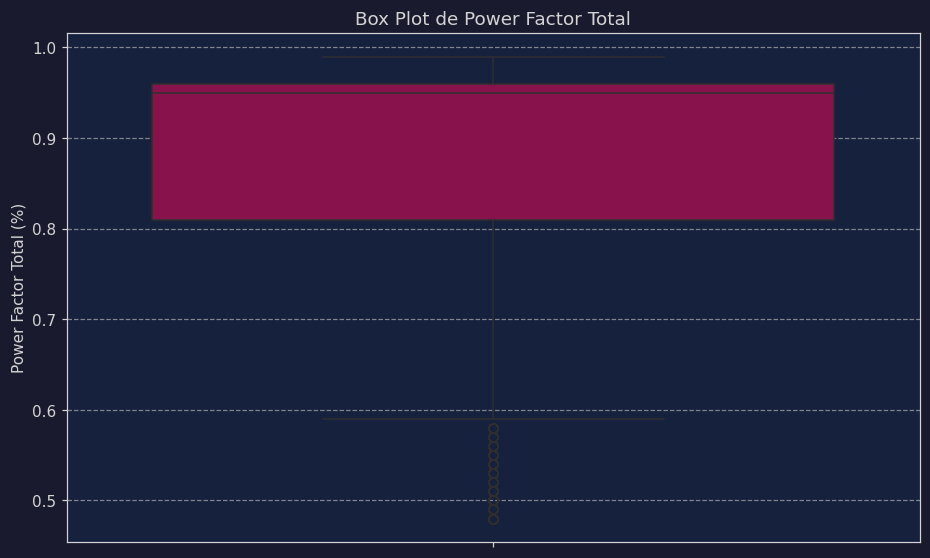

In [58]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_raw['power_factor_total_pct'], color=COLOR_PRINCIPAL)
plt.title('Box Plot de Power Factor Total', color=COLOR_GRIS)
plt.ylabel('Power Factor Total (%)', color=COLOR_GRIS)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Ahora, vamos a identificar los outliers de manera programática usando el método del rango intercuartílico (IQR).

In [59]:
Q1 = df_raw['power_factor_total_pct'].quantile(0.25)
Q3 = df_raw['power_factor_total_pct'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_raw[(df_raw['power_factor_total_pct'] < lower_bound) | (df_raw['power_factor_total_pct'] > upper_bound)]

print(f"Q1 (25th percentile): {Q1:.2f}")
print(f"Q3 (75th percentile): {Q3:.2f}")
print(f"IQR (Interquartile Range): {IQR:.2f}")
print(f"Lower Bound for Outliers: {lower_bound:.2f}")
print(f"Upper Bound for Outliers: {upper_bound:.2f}")

print(f"\nNumber of outliers detected: {len(outliers)}")
display(outliers[['timestamp', 'power_factor_total_pct']].head())

Q1 (25th percentile): 0.81
Q3 (75th percentile): 0.96
IQR (Interquartile Range): 0.15
Lower Bound for Outliers: 0.59
Upper Bound for Outliers: 1.18

Number of outliers detected: 1165


,timestamp,power_factor_total_pct
2,2024-08-01 00:10:00,0.52
3,2024-08-01 00:15:00,0.50
5,2024-08-01 00:25:00,0.48
6,2024-08-01 00:30:00,0.54
7,2024-08-01 00:35:00,0.56


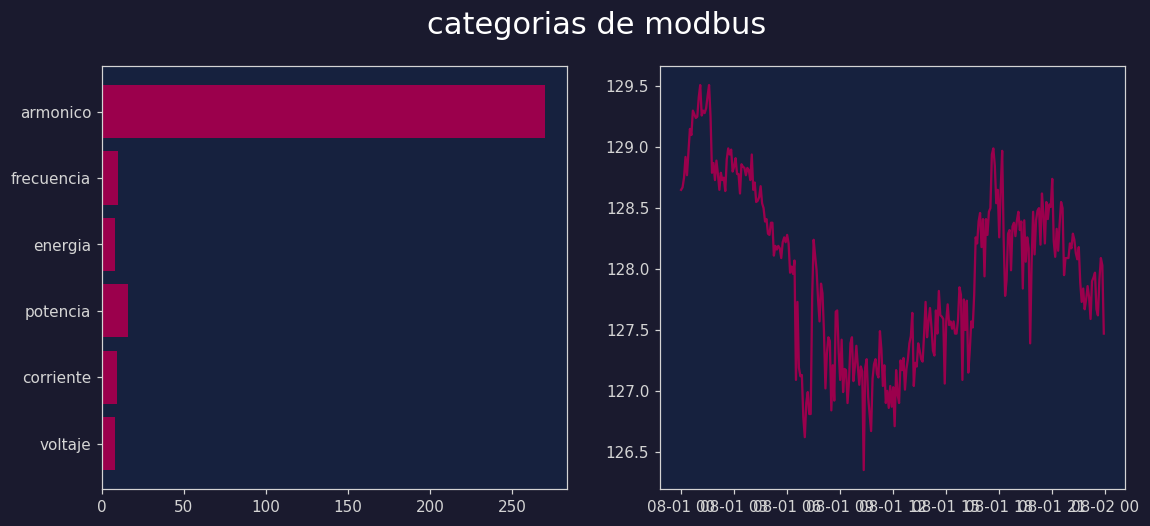

In [63]:
from matplotlib import color_sequences
fig,axes=plt.subplots(1,2,figsize=(12,5))
fig.suptitle("categorias de modbus", # Corrected to fig.suptitle
             color = "white",
             fontsize = 20
)

ax1 =axes [0]

nombres = list (categorias.keys())

valores =[len(v) for v in categorias.values()]

barras = ax1.barh(nombres,valores,color=COLOR_PRINCIPAL)

ax2 = axes [1]

fecha_d1 = df_raw["timestamp"].min()

d1=df_raw[df_raw['timestamp'].dt.date == fecha_d1.date()]

ax2.plot(d1["timestamp"],d1["voltage_avg_V"], color=COLOR_PRINCIPAL)
plt.show()